# Save the data in the right format

In [1]:
import numpy as np
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt
import random
import math

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from dataset import SuperResolutionDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import time

import torchmetrics
from skimage.metrics import structural_similarity as ssim

from tqdm import tqdm


import wandb



In [3]:
# Preprocess and save npy arrays into hdf5 files
jw = np.load('../data/jwst_cosmos_205px_F115W.npy')
eu = np.load('../data/euclid_NIR_cosmos_41px_Y.npy')


In [ ]:
import os
import h5py
import numpy as np
from scipy import ndimage
from tqdm import tqdm

# === CONFIG ===
euclid_data = eu  # shape (N, 41, 41)
jwst_data = jw    # shape (N, 205, 205)
hdf5_lr_path = "../data/Nisp_train_cosmos.hdf5"
hdf5_hr_path = "../data/Nircam_train_cosmos.hdf5"

# === REMOVE OLD FILES ===
for path in [hdf5_lr_path, hdf5_hr_path]:
    if os.path.exists(path):
        os.remove(path)

# === SPLIT INDICES ===
sample_size = len(jwst_data)
train_size = int(sample_size * 0.8)
test_size = sample_size - train_size

indices = np.arange(sample_size)
np.random.shuffle(indices)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# === CROP HELPERS ===
def center_crop(image, crop_size):
    h, w = image.shape
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return image[start_h:start_h+crop_size, start_w:start_w+crop_size]

# === NORMALIZATION FUNCTION WITH CROPPING ===
def preprocess_pair(eu_img, jw_img, apply_rotation=False):
    if apply_rotation:
        eu_img = ndimage.rotate(eu_img, 0, mode='nearest', reshape=False)
        jw_img = ndimage.rotate(jw_img, 0, mode='nearest', reshape=False)

    eu_asinh = np.arcsinh(eu_img)
    jw_asinh = np.arcsinh(jw_img)

    min_val = min(eu_asinh.min(), jw_asinh.min())
    max_val = max(eu_asinh.max(), jw_asinh.max())
    range_val = max_val - min_val + 1e-8

    eu_norm = np.clip((eu_asinh - min_val) / range_val, 0, 1)
    jw_norm = np.clip((jw_asinh - min_val) / range_val, 0, 1)

    # === CROP TO 25×25 and 125×125 ===
    eu_crop = center_crop(eu_norm, 25)
    jw_crop = center_crop(jw_norm, 125)

    return eu_crop[np.newaxis, ...].astype(np.float32), jw_crop[np.newaxis, ...].astype(np.float32)

# === CREATE HDF5 STRUCTURE (no compression) ===
def create_hdf5_file(path, shape_lr, shape_hr, train_size, test_size):
    f = h5py.File(path, mode='w')
    f.create_dataset("train_img", (train_size,) + shape_lr, dtype=np.float32)
    f.create_dataset("test_img", (test_size,) + shape_lr, dtype=np.float32)
    f.create_dataset("train_keys", (train_size,), dtype=np.int32)
    f.create_dataset("test_keys", (test_size,), dtype=np.int32)
    return f

hdf5_lr = create_hdf5_file(hdf5_lr_path, (1, 25, 25), None, train_size, test_size)
hdf5_hr = create_hdf5_file(hdf5_hr_path, (1, 125, 125), None, train_size, test_size)

hdf5_lr["train_keys"][...] = train_indices
hdf5_lr["test_keys"][...] = test_indices
hdf5_hr["train_keys"][...] = train_indices
hdf5_hr["test_keys"][...] = test_indices

# === PROCESS AND STORE ===
def store_split(indices, split, hdf5_lr, hdf5_hr):
    for i, idx in tqdm(enumerate(indices), total=len(indices), desc=f"Storing {split}"):
        eu_img = euclid_data[idx]
        jw_img = jwst_data[idx]
        eu_processed, jw_processed = preprocess_pair(eu_img, jw_img)
        hdf5_lr[f"{split}_img"][i] = eu_processed
        hdf5_hr[f"{split}_img"][i] = jw_processed

store_split(train_indices, "train", hdf5_lr, hdf5_hr)
store_split(test_indices, "test", hdf5_lr, hdf5_hr)

hdf5_lr.close()
hdf5_hr.close()

print("✅ Preprocessing complete with center crops (25x25, 125x125).")


# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [6]:
train_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="train"
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 25, 25)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 125, 125)

test_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test"
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 25, 25)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 125, 125)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 25, 25])
HR Batch Shape: torch.Size([16, 1, 125, 125])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 25, 25])
HR Batch Shape: torch.Size([16, 1, 125, 125])


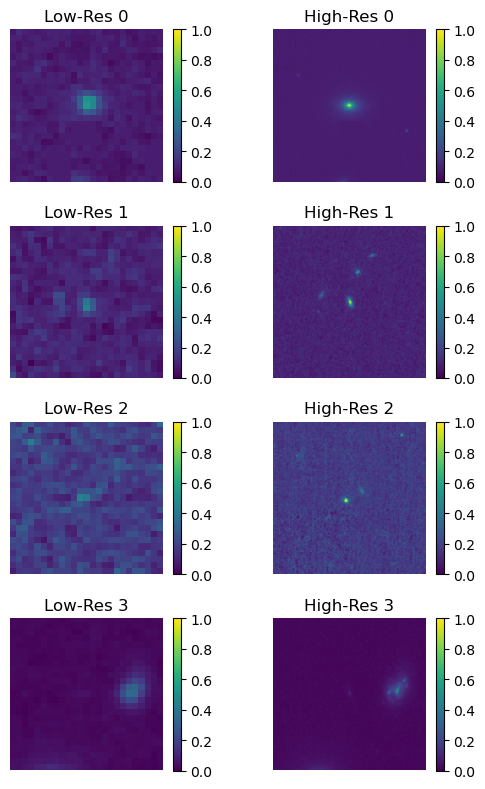

In [9]:
lr_hdf5_path = "../data/Nisp_train_cosmos.hdf5"
hr_hdf5_path = "../data/Nircam_train_cosmos.hdf5"

# === Load Training Dataset ===
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# === Fetch a batch from the training dataset ===
lr_batch, hr_batch = next(iter(train_loader))

# === Convert tensors to NumPy ===
lr_batch_np = lr_batch.squeeze(1).cpu().numpy()  
hr_batch_np = hr_batch.squeeze(1).cpu().numpy()  

# === Shared color scale ===
vmin = min(lr_batch_np.min(), hr_batch_np.min())
vmax = max(lr_batch_np.max(), hr_batch_np.max())

# === Plot first 4 samples ===
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig("superres_examples.png", dpi=300)  # Uncomment to save
plt.show()


# Diffusion based model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# === Timestep Embedding ===
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    exponent = -torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * (math.log(10000.0) / (half_dim - 1))
    emb = timesteps.float().unsqueeze(1) * torch.exp(exponent.unsqueeze(0))
    return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

# === UNet (for 125x125) ===
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64, activation_fn=nn.ReLU, time_embed_dim=128):
        super().__init__()
        self.activation_fn = activation_fn

        # Encoder: 125 → 62 → 31 → 15
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 4, 2, 1),
            activation_fn()
        )
        self.encoder2 = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1),
            activation_fn()
        )
        self.encoder3 = nn.Sequential(
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1),
            activation_fn()
        )

        # Conditioning + time
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, 3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, hidden_dim * 4),
            activation_fn()
        )
        self.cross_attention = nn.Conv2d(hidden_dim * 8, hidden_dim * 4, 1)

        # Decoder: 15 → 30 → 60 → 120
        self.decoder1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(hidden_dim * 4, hidden_dim * 2, 3, padding=1),
            activation_fn()
        )
        self.decoder2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(hidden_dim * 2, hidden_dim, 3, padding=1),
            activation_fn()
        )
        self.decoder3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, 3, padding=1),
            activation_fn()
        )
        self.output_conv = nn.Conv2d(hidden_dim // 2, out_channels, 3, padding=1)

    def forward(self, x, condition, t_embed):
        x1 = self.encoder1(x)   # 125 → 62
        x2 = self.encoder2(x1)  # 62 → 31
        x3 = self.encoder3(x2)  # 31 → 15

        cond = self.condition_proj(condition)
        cond = F.interpolate(cond, size=x3.shape[2:], mode="bilinear", align_corners=True)

        t_proj = self.time_mlp(t_embed).view(x3.size(0), -1, 1, 1).expand(-1, -1, x3.size(2), x3.size(3))
        x3 = torch.cat([x3 + t_proj, cond], dim=1)
        x3 = self.cross_attention(x3)

        x = self.decoder1(x3)
        x = self.align_dims(x, x2)
        x = x + x2

        x = self.decoder2(x)
        x = self.align_dims(x, x1)
        x = x + x1

        x = self.decoder3(x)
        x = self.output_conv(x)

        return self.align_dims(x, (125, 125))

    def align_dims(self, x, target):
        if isinstance(target, torch.Tensor):
            target_h, target_w = target.size(2), target.size(3)
        else:
            target_h, target_w = target
        diffY = target_h - x.size(2)
        diffX = target_w - x.size(3)
        return F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])

# === Upsampler: 25x25 → 125x125 ===
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64 * 4, 3, padding=1),
            nn.PixelShuffle(2),  # 25 → 50
            nn.ReLU(),
            nn.Conv2d(64, 64 * 4, 3, padding=1),
            nn.PixelShuffle(2),  # 50 → 100
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.Conv2d(64, out_channels, 3, padding=1),
        )

    def forward(self, x):
        x = self.block(x)
        return F.interpolate(x, size=(125, 125), mode='bilinear', align_corners=False)

# === Cosine Noise Schedule ===
def cosine_schedule(t, total_timesteps=500):
    return torch.cos((t / total_timesteps) * (0.5 * torch.pi))

# === Diffusion Wrapper ===
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=500, time_embed_dim=128):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps
        self.time_embed_dim = time_embed_dim

    def forward(self, x, t, condition):
        t_embed = get_timestep_embedding(t, self.time_embed_dim)
        return self.unet(x, condition, t_embed)

# === Full Super-Resolution Diffusion Pipeline ===
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        upscaled = self.upsampler(x)  # → (B, 1, 125, 125)
        noise = torch.randn_like(upscaled)
        alpha_t = cosine_schedule(t, self.diffusion.timesteps).view(-1, 1, 1, 1)
        noisy = alpha_t * upscaled + (1 - alpha_t) * noise
        return self.diffusion(noisy, t, upscaled)

# === Example Run ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet().to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

x = torch.randn(1, 1, 25, 25, device=device)
t = torch.tensor([250], dtype=torch.float32, device=device)
output = model(x, t)
print("✅ Output shape:", output.shape)  # Should be (1, 1, 125, 125)


✅ Output shape: torch.Size([1, 1, 125, 125])


# Train

In [15]:
# === Setup ===
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 2  # 🔹Quick test

train_loader = DataLoader(
    SuperResolutionDataset(
        "../data/Nisp_train_cosmos.hdf5",
        "../data/Nircam_train_cosmos.hdf5",
        split="train",
        sample_fraction=0.1  # 🔹Optional: reduce dataset
    ),
    batch_size=8,  # 🔹Smaller batch
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

# === Train ===
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()
    print(f"🚀 Starting Epoch {epoch+1}")

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.size(0),), device=device)

        noise = torch.randn_like(hr_batch)
        alpha_t = cosine_schedule(t, model.diffusion.timesteps).view(-1, 1, 1, 1)
        noisy_hr = alpha_t * hr_batch + (1 - alpha_t) * noise

        predicted_noise = model(lr_batch, t)
        loss = criterion(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f} | Time: {time.time() - start_time:.2f}s")

torch.save(model.state_dict(), "super_resolution_model_test.pth")
print("📦 Model saved successfully!")


🚀 Starting Epoch 1
✅ Epoch [1/2] Loss: 0.999937 | Time: 292.66s
🚀 Starting Epoch 2
✅ Epoch [2/2] Loss: 0.999948 | Time: 303.04s
📦 Model saved successfully!


In [17]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model has {count_parameters(model) / 1e6:.2f} million trainable parameters")


Model has 1.54 million trainable parameters


# Evaluate 

/var/folders/3t/27bzm_5577qbf5908lwjw0l00000gp/T/ipykernel_42649/1133744628.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
/opt/anaconda3/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


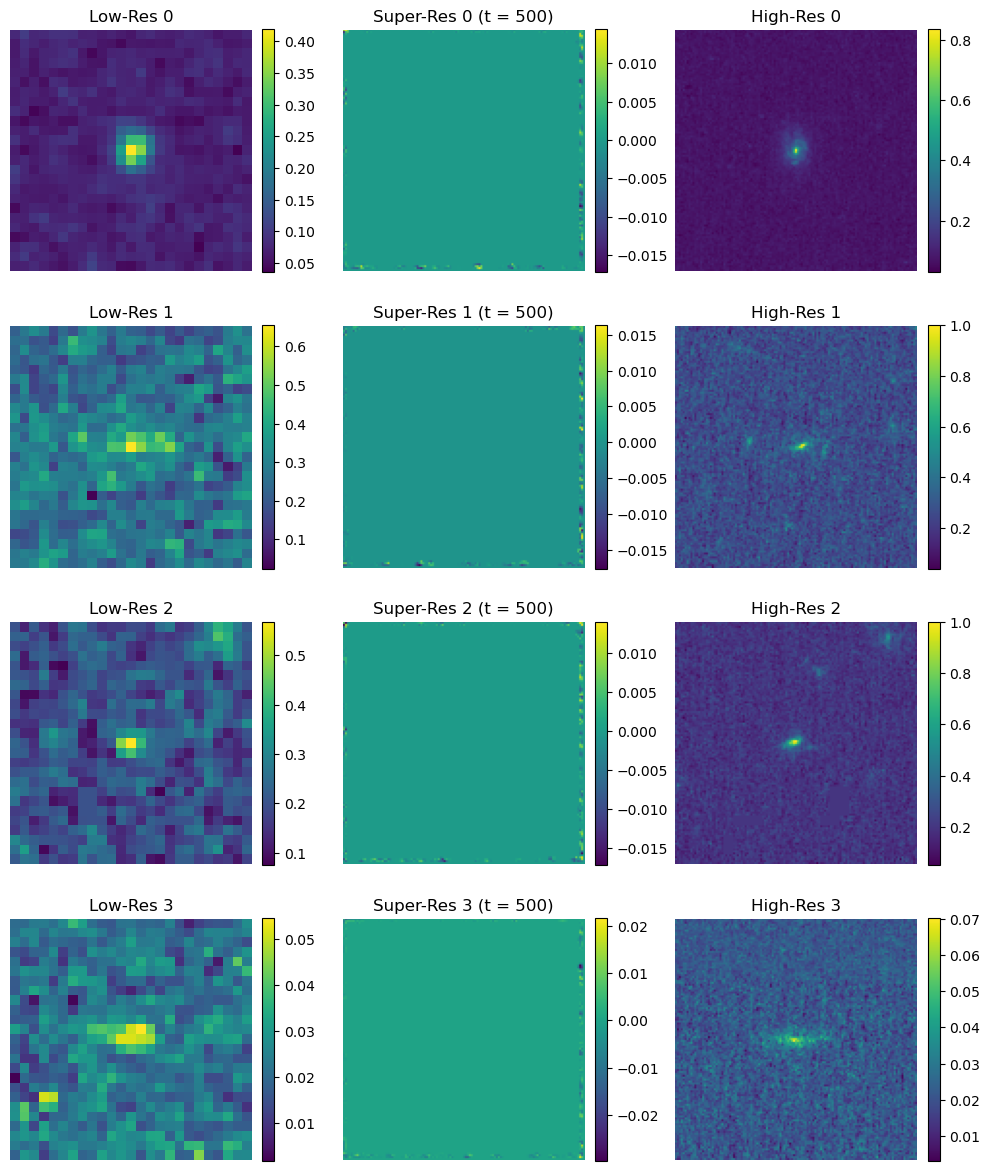

In [24]:
# Load model
checkpoint_path = "super_resolution_model_test.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed

test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test", sample_fraction=1),
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


# === Pick a random test batch ===
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# === Inference with timestep t (adjustable) ===
t_value = 500 # You can try 0, 50, 100, 250, etc.
t_test = torch.full((lr_batch.shape[0],), t_value, dtype=torch.long, device=device)

with torch.no_grad(), torch.cuda.amp.autocast():
    sr_batch = model(lr_batch, t_test).cpu()

# === Convert to numpy for visualization ===
lr_batch_np = lr_batch.cpu().squeeze().numpy()
sr_batch_np = sr_batch.squeeze().numpy()
hr_batch_np = hr_batch.cpu().squeeze().numpy()

# === Plot results ===
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Res
    img1 = axes[i, 0].imshow(lr_batch_np[i])
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved (Refined)
    img2 = axes[i, 1].imshow(sr_batch_np[i])
    axes[i, 1].set_title(f"Super-Res {i} (t = {t_value})")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Res Ground Truth
    img3 = axes[i, 2].imshow(hr_batch_np[i])
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



In [ ]:
# PSNR function using torchmetrics
def compute_psnr(pred, target):
    psnr = torchmetrics.functional.image.peak_signal_noise_ratio(pred, target)
    return psnr.item()

# SSIM function using skimage
def compute_ssim(pred, target):
    pred_np = pred.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    return ssim(pred_np, target_np, data_range=target_np.max() - target_np.min())

# Set model to evaluation mode
model.eval()

# Fetch a test batch from test_loader
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test"),
    batch_size=1, shuffle=True, num_workers=0  
)

lr_test, hr_test = next(iter(test_loader))  
lr_test, hr_test = lr_test.to(device), hr_test.to(device)

# Generate super-resolution image
with torch.no_grad():
    t_test = torch.tensor([0], device=device)  # At t=0 for final reconstruction
    predicted_hr = model(lr_test, t_test).cpu()  # Move result to CPU

# Compute PSNR & SSIM
psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.3f}")


In [ ]:
total_psnr = 0.0
total_ssim = 0.0
num_batches = 0

model.eval()
with torch.no_grad():
    for lr_test, hr_test in test_loader:
        lr_test, hr_test = lr_test.to(device), hr_test.to(device)
        t_test = torch.tensor([0], device=device)
        predicted_hr = model(lr_test, t_test).cpu()
        
        psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
        ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

        total_psnr += psnr_value
        total_ssim += ssim_value
        num_batches += 1

avg_psnr = total_psnr / num_batches
avg_ssim = total_ssim / num_batches

print(f"Average PSNR: {avg_psnr:.2f} dB")
print(f"Average SSIM: {avg_ssim:.3f}")
